# Visualisation des KPIs — Couche Gold (MongoDB)

Ce notebook se connecte directement à MongoDB et affiche chaque KPI calculé par `spark/gold_job.py` sous forme de graphique.

**Prérequis :** MongoDB doit tourner (`docker compose up -d mongodb`) et la couche Gold doit avoir été générée (`make gold`).

In [9]:
import glob, json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

GOLD_EXPORT_PATH = "../data/gold_export"

def load_kpi(name):
    with open(f"{GOLD_EXPORT_PATH}/{name}.json", encoding="utf-8") as f:
        data = json.load(f)
    df = pd.json_normalize(data)
    return df.drop(columns=[c for c in df.columns if c == "_id"], errors="ignore")

print("Fichiers disponibles :", [f.split("/")[-1] for f in glob.glob(f"{GOLD_EXPORT_PATH}/*.json")])

Fichiers disponibles : ['gold_export\\kpi_daily_revenue.json', 'gold_export\\kpi_global_summary.json', 'gold_export\\kpi_monthly_stats.json', 'gold_export\\kpi_price_by_day.json', 'gold_export\\kpi_price_by_hour.json', 'gold_export\\kpi_tip_by_payment.json', 'gold_export\\kpi_top_dropoff_zones.json', 'gold_export\\kpi_top_pickup_zones.json', 'gold_export\\kpi_weekday_vs_weekend.json']


## 1. Synthèse globale

In [10]:
summary = load_kpi("kpi_global_summary")
summary

,avg_price,nb_trips,avg_distance,avg_duration_minutes,avg_tip,_id.$oid
0,29.356654,42402283,3.429549,17.13871,3.689031,6a6c6188e13ea753a0dfc31c


## 2. Revenu journalier

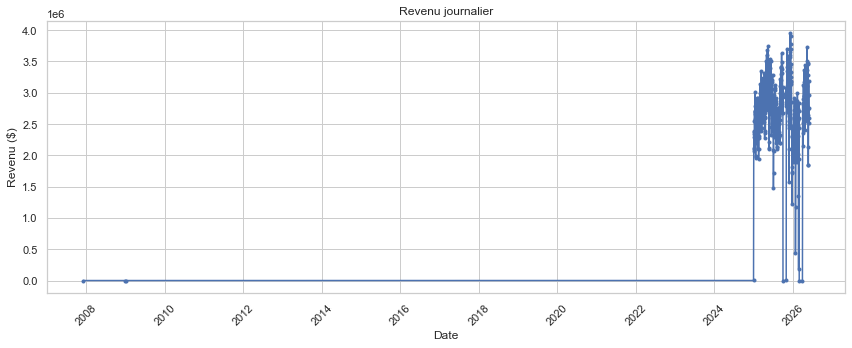

In [15]:
daily_revenue = load_kpi("kpi_daily_revenue").sort_values("pickup_date.$date")

plt.figure(figsize=(12, 5))
plt.plot(
    pd.to_datetime(daily_revenue["pickup_date.$date"]),
    daily_revenue["daily_revenue"],
    marker="o",
    markersize=3
)

plt.title("Revenu journalier")
plt.xlabel("Date")
plt.ylabel("Revenu ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
print(load_kpi("kpi_daily_revenue").columns.tolist())

['daily_revenue', 'nb_trips', '_id.$oid', 'pickup_date.$date']


## 3. Top zones de départ

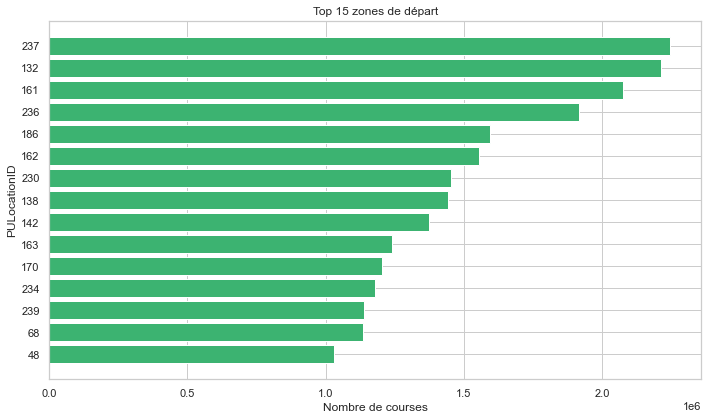

In [16]:
top_pickup = load_kpi("kpi_top_pickup_zones").sort_values("nb_trips", ascending=True).tail(15)

plt.figure(figsize=(10, 6))
plt.barh(top_pickup["PULocationID"].astype(str), top_pickup["nb_trips"], color="mediumseagreen")
plt.title("Top 15 zones de départ")
plt.xlabel("Nombre de courses")
plt.ylabel("PULocationID")
plt.tight_layout()
plt.show()

## 4. Top zones d'arrivée

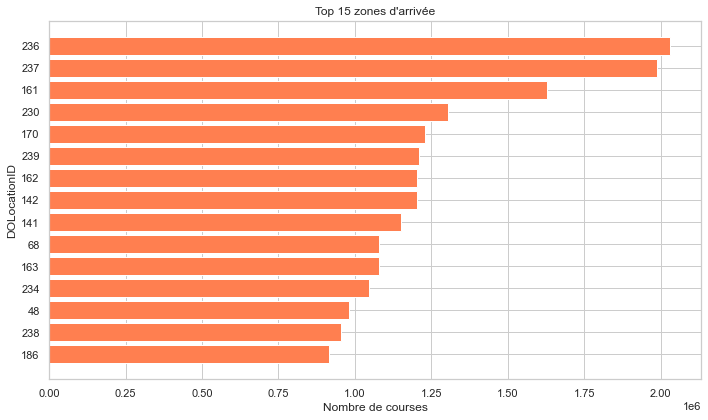

In [17]:
top_dropoff = load_kpi("kpi_top_dropoff_zones").sort_values("nb_trips", ascending=True).tail(15)

plt.figure(figsize=(10, 6))
plt.barh(top_dropoff["DOLocationID"].astype(str), top_dropoff["nb_trips"], color="coral")
plt.title("Top 15 zones d'arrivée")
plt.xlabel("Nombre de courses")
plt.ylabel("DOLocationID")
plt.tight_layout()
plt.show()

## 5. Prix moyen par heure

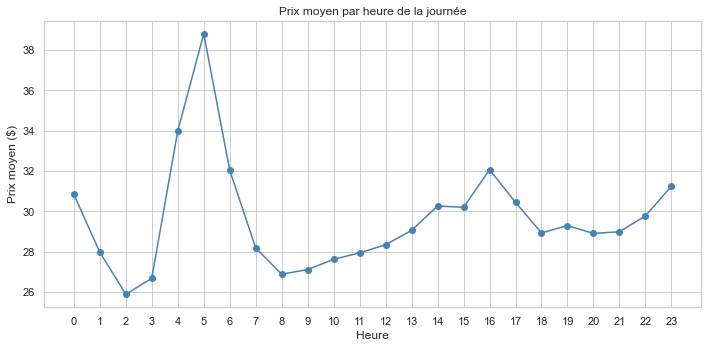

In [18]:
price_by_hour = load_kpi("kpi_price_by_hour").sort_values("pickup_hour")

plt.figure(figsize=(10, 5))
plt.plot(price_by_hour["pickup_hour"], price_by_hour["avg_price"], marker="o", color="steelblue")
plt.title("Prix moyen par heure de la journée")
plt.xlabel("Heure")
plt.ylabel("Prix moyen ($)")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

## 6. Prix moyen par jour de la semaine

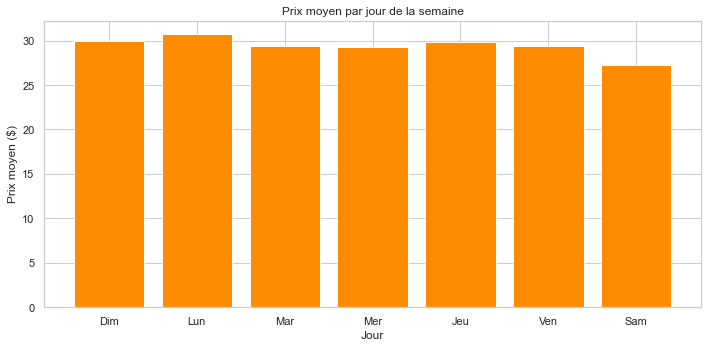

In [19]:
price_by_day = load_kpi("kpi_price_by_day").sort_values("pickup_dayofweek")
day_labels = {1: "Dim", 2: "Lun", 3: "Mar", 4: "Mer", 5: "Jeu", 6: "Ven", 7: "Sam"}
price_by_day["day_label"] = price_by_day["pickup_dayofweek"].map(day_labels)

plt.figure(figsize=(10, 5))
plt.bar(price_by_day["day_label"], price_by_day["avg_price"], color="darkorange")
plt.title("Prix moyen par jour de la semaine")
plt.xlabel("Jour")
plt.ylabel("Prix moyen ($)")
plt.tight_layout()
plt.show()

## 7. Semaine vs week-end

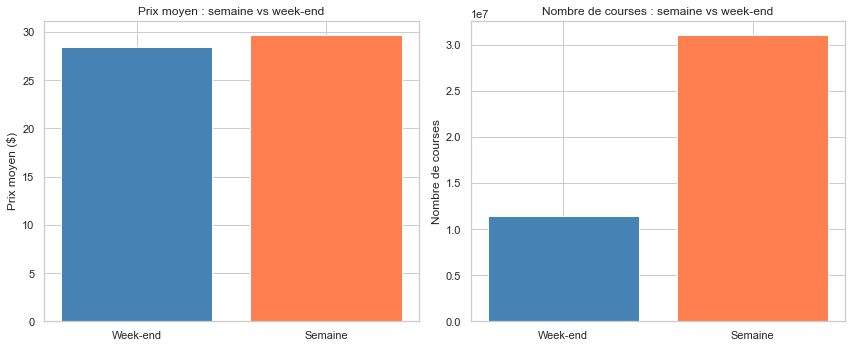

In [20]:
weekday_vs_weekend = load_kpi("kpi_weekday_vs_weekend")
weekday_vs_weekend["label"] = weekday_vs_weekend["is_weekend"].map({True: "Week-end", False: "Semaine"})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(weekday_vs_weekend["label"], weekday_vs_weekend["avg_price"], color=["steelblue", "coral"])
axes[0].set_title("Prix moyen : semaine vs week-end")
axes[0].set_ylabel("Prix moyen ($)")

axes[1].bar(weekday_vs_weekend["label"], weekday_vs_weekend["nb_trips"], color=["steelblue", "coral"])
axes[1].set_title("Nombre de courses : semaine vs week-end")
axes[1].set_ylabel("Nombre de courses")

plt.tight_layout()
plt.show()

## 8. Pourboire moyen par mode de paiement

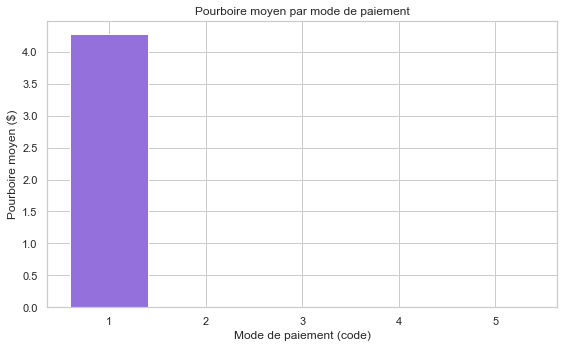

In [21]:
tip_by_payment = load_kpi("kpi_tip_by_payment").sort_values("payment_type")

plt.figure(figsize=(8, 5))
plt.bar(tip_by_payment["payment_type"].astype(str), tip_by_payment["avg_tip"], color="mediumpurple")
plt.title("Pourboire moyen par mode de paiement")
plt.xlabel("Mode de paiement (code)")
plt.ylabel("Pourboire moyen ($)")
plt.tight_layout()
plt.show()

## 9. Distance et durée moyennes par mois

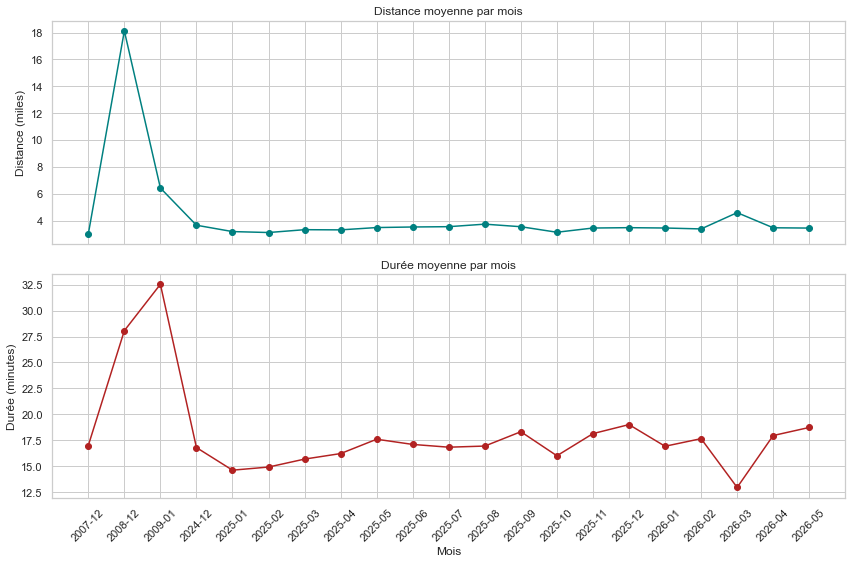

In [22]:
monthly_stats = load_kpi("kpi_monthly_stats").sort_values(["year", "month"])
monthly_stats["period"] = monthly_stats["year"].astype(str) + "-" + monthly_stats["month"].astype(str).str.zfill(2)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(monthly_stats["period"], monthly_stats["avg_distance"], marker="o", color="teal")
axes[0].set_title("Distance moyenne par mois")
axes[0].set_ylabel("Distance (miles)")

axes[1].plot(monthly_stats["period"], monthly_stats["avg_duration_minutes"], marker="o", color="firebrick")
axes[1].set_title("Durée moyenne par mois")
axes[1].set_ylabel("Durée (minutes)")
axes[1].set_xlabel("Mois")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()